In [1]:
# ===============================================
# 1) Install And Import Libraries
# ===============================================

print("Installing comet_ml...")
!pip install comet_ml --quiet
print("Installation complete!\n")

import gc
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import comet_ml
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy

Installing comet_ml...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.6/796.6 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.2 MB/s eta 0:00:00
Installation complete!



In [2]:
# ===============================================
# 2) Check Environment And Login To Comet ML
# ===============================================

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU device: {tf.test.gpu_device_name()}")
print()

comet_ml.login()

TensorFlow version: 2.20.0
GPU device: /device:GPU:0

Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)
Comet API key: ··········


COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).


In [3]:
# ===============================================
# 3) Global Settings
# ===============================================

BATCH_SIZE = 32
img_height = 180
img_width = 180
EPOCHS = 50

SEED = 123
tf.keras.utils.set_random_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# ===============================================
# 4) Download And Check Flower Dataset
# ===============================================

print("Downloading flower photos dataset...")

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

archive_path = tf.keras.utils.get_file(
    origin=dataset_url,
    fname="flower_photos.tgz",
    extract=True
)

base_dir = pathlib.Path(archive_path).parent

data_dir = None

possible_paths = [
    base_dir / "flower_photos",
    pathlib.Path(str(base_dir).replace("/flower_photos", "")) / "flower_photos"
]

for path in possible_paths:
    if path.exists() and (path / "daisy").exists():
        data_dir = path
        break

if data_dir is None:
    all_subdirs = list(base_dir.rglob("daisy"))
    if all_subdirs:
        data_dir = all_subdirs[0].parent

if data_dir is None or not data_dir.exists():
    raise FileNotFoundError(f"Dataset directory not found. Searched in: {base_dir}")

print(f"Dataset path: {data_dir}")

subdirs = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print(f"Subdirectories: {subdirs}")

total_images = 0
for subdir in subdirs:
    num_images = len(list((data_dir / subdir).glob("*.jpg")))
    total_images += num_images
    print(f"   - {subdir}: {num_images} images")

print(f"   Total: {total_images} images")
print()

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Dataset path: /root/.keras/datasets/flower_photos_extracted/flower_photos
Subdirectories: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
   - daisy: 633 images
   - dandelion: 898 images
   - roses: 641 images
   - sunflowers: 699 images
   - tulips: 799 images
   Total: 3670 images



In [5]:
# ===============================================
# 5) Load Train, Validation, And Test Datasets
# ===============================================

def collect_image_paths_and_labels(data_dir):

    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    image_paths = []
    labels = []

    for class_index, class_name in enumerate(class_names):
        class_dir = data_dir / class_name

        class_files = []
        class_files.extend(sorted(class_dir.glob("*.jpg")))
        class_files.extend(sorted(class_dir.glob("*.jpeg")))
        class_files.extend(sorted(class_dir.glob("*.png")))

        for file_path in class_files:
            image_paths.append(str(file_path))
            labels.append(class_index)

    image_paths = np.array(image_paths)
    labels = np.array(labels, dtype=np.int32)

    return image_paths, labels, class_names

def stratified_split(image_paths, labels, train_ratio=0.75, val_ratio=0.15, seed=SEED):

    rng = np.random.default_rng(seed)

    train_indices = []
    val_indices = []
    test_indices = []

    num_classes = len(np.unique(labels))

    for class_id in range(num_classes):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)

        num_samples = len(class_indices)
        num_train = int(num_samples * train_ratio)
        num_val = int(num_samples * val_ratio)

        class_train = class_indices[:num_train]
        class_val = class_indices[num_train:num_train + num_val]
        class_test = class_indices[num_train + num_val:]

        train_indices.extend(class_train)
        val_indices.extend(class_val)
        test_indices.extend(class_test)

    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return (
        image_paths[train_indices],
        labels[train_indices],
        image_paths[val_indices],
        labels[val_indices],
        image_paths[test_indices],
        labels[test_indices]
    )

def load_image(image_path, label):

    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [img_height, img_width])

    return image, label

def make_tf_dataset(image_paths, labels, batch_size=BATCH_SIZE, shuffle=False):

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)

    return ds

def print_split_distribution(name, labels, class_names):

    counts = np.bincount(labels, minlength=len(class_names))

    print(f"{name} size: {len(labels)}")
    for class_name, count in zip(class_names, counts):
        print(f"   - {class_name}: {count}")

def get_dataset():

    image_paths, labels, class_names = collect_image_paths_and_labels(data_dir)

    num_classes = len(class_names)

    print(f"Classes: {class_names}")
    print(f"Number of classes: {num_classes}")

    if num_classes != 5:
        raise ValueError(f"Expected 5 classes but found {num_classes}!")

    (
        train_paths,
        train_labels,
        val_paths,
        val_labels,
        test_paths,
        test_labels
    ) = stratified_split(
        image_paths=image_paths,
        labels=labels,
        train_ratio=0.75,
        val_ratio=0.15,
        seed=SEED
    )

    print("\nStratified split distribution:")
    print_split_distribution("Train", train_labels, class_names)
    print_split_distribution("Validation", val_labels, class_names)
    print_split_distribution("Test", test_labels, class_names)
    print()

    train_ds = make_tf_dataset(
        train_paths,
        train_labels,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_ds = make_tf_dataset(
        val_paths,
        val_labels,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = make_tf_dataset(
        test_paths,
        test_labels,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_ds, val_ds, test_ds, class_names, num_classes

train_raw_ds, val_raw_ds, test_raw_ds, class_names, num_classes = get_dataset()
print()

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5

Stratified split distribution:
Train size: 2750
   - daisy: 474
   - dandelion: 673
   - roses: 480
   - sunflowers: 524
   - tulips: 599
Validation size: 547
   - daisy: 94
   - dandelion: 134
   - roses: 96
   - sunflowers: 104
   - tulips: 119
Test size: 373
   - daisy: 65
   - dandelion: 91
   - roses: 65
   - sunflowers: 71
   - tulips: 81




In [6]:
# ===============================================
# 6) Data Augmentation And Preprocessing
# ===============================================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED + 1),
    layers.RandomZoom(0.1, seed=SEED + 2),
    layers.RandomTranslation(
        height_factor=0.2,
        width_factor=0.2,
        seed=SEED + 3
    )
], name="data_augmentation")

def prepare_train(ds):

    ds = ds.cache()

    ds = ds.shuffle(
        buffer_size=1000,
        seed=SEED,
        reshuffle_each_iteration=True
    )

    ds = ds.map(
        lambda x, y: (data_augmentation(x, training=True) / 255.0, y),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds

def prepare_val(ds):

    ds = ds.map(
        lambda x, y: (x / 255.0, y),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.cache()
    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds

train_ds = prepare_train(train_raw_ds)
val_ds = prepare_val(val_raw_ds)
test_ds = prepare_val(test_raw_ds)

print("Dataset preprocessing complete!")
print("   Training: with data augmentation + normalization")
print("   Validation: with normalization only (no augmentation)")
print("   Test: with normalization only (no augmentation)")
print()

Dataset preprocessing complete!
   Training: with data augmentation + normalization
   Validation: with normalization only (no augmentation)
   Test: with normalization only (no augmentation)



Visualizing data augmentation examples...


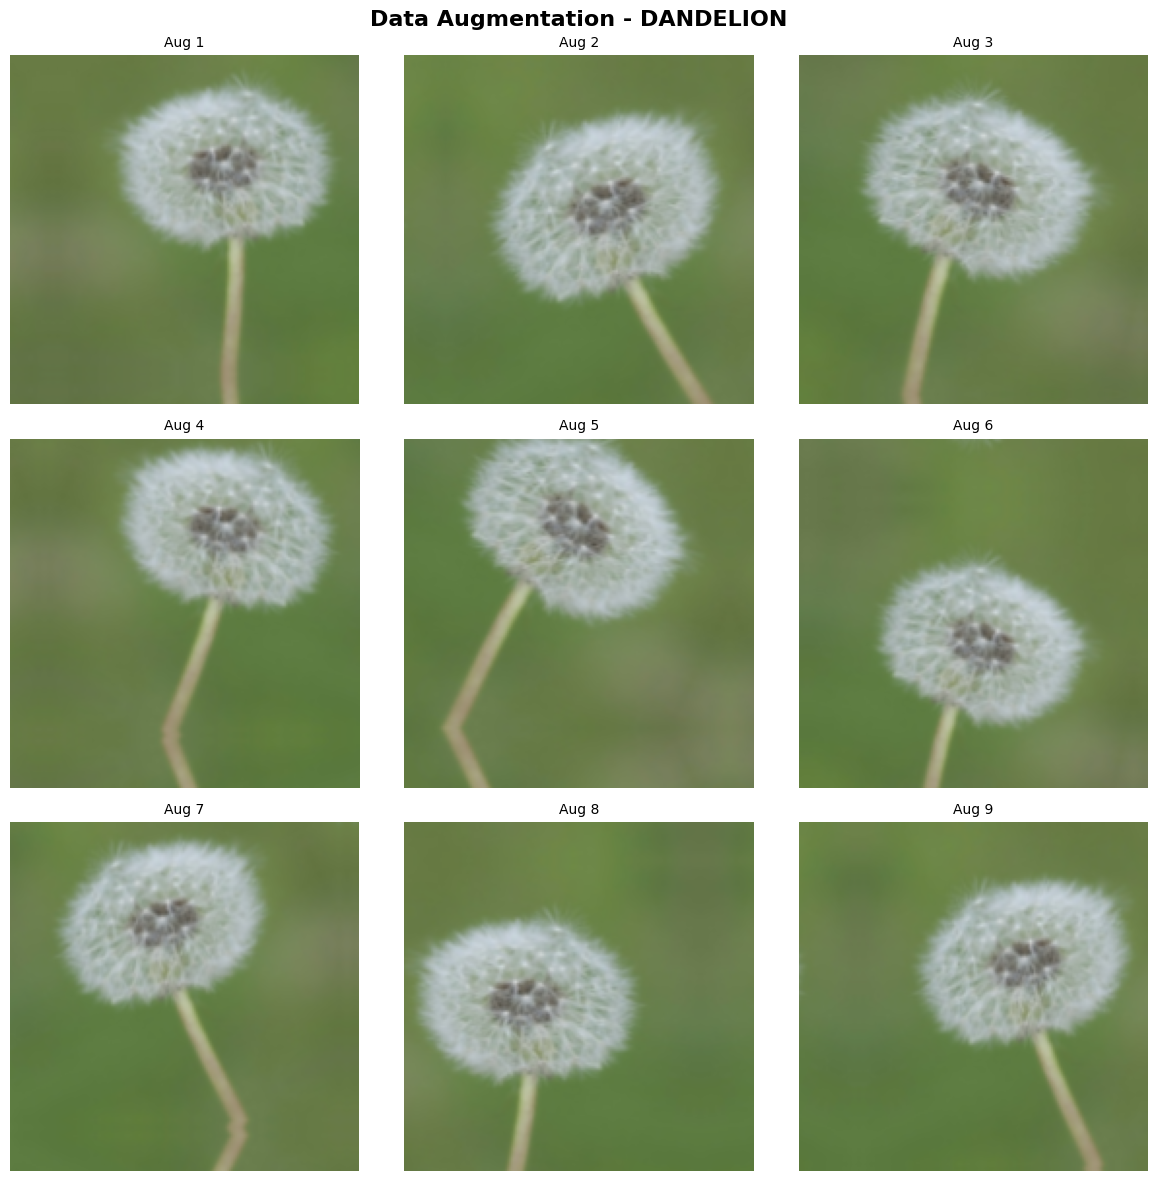

In [7]:
# ===============================================
# 7) Visualize Data Augmentation
# ===============================================

print("Visualizing data augmentation examples...")

plt.figure(figsize=(12, 12))

for images, labels in train_raw_ds.take(1):
    single_image = images[0:1] / 255.0
    class_name = class_names[labels[0].numpy()]

    for i in range(9):
        augmented = data_augmentation(single_image, training=True)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0])
        plt.axis("off")
        plt.title(f"Aug {i + 1}", fontsize=10)

    plt.suptitle(
        f"Data Augmentation - {class_name.upper()}",
        fontsize=16,
        fontweight="bold"
    )
    break

plt.tight_layout()
plt.show()
print()

In [8]:
# ===============================================
# 8) Optimizer Factory Function
# ===============================================

def get_optimizer(optz_name):

    if optz_name == "adam":
        return keras.optimizers.Adam(learning_rate=0.001)

    elif optz_name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=0.001)

    elif optz_name == "sgd":
        return keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    elif optz_name == "nadam":
        return keras.optimizers.Nadam(learning_rate=0.001)

    elif optz_name == "adagrad":
        return keras.optimizers.Adagrad(learning_rate=0.01)

    else:
        raise ValueError(f"Unknown optimizer: {optz_name}")

In [9]:
# ===============================================
# 9) Model Architecture
# ===============================================

def build_model_graph(experiment):

    optz_name = experiment.get_parameter("optz")

    optimizer = get_optimizer(optz_name)

    model = Sequential([
        layers.Input(shape=(img_height, img_width, 3)),

        layers.Conv2D(32, (3, 3), use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes)
    ], name="flower_classifier")

    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [10]:
# ===============================================
# 10) Training Function
# ===============================================

def train(model, train_ds, val_ds, epochs):

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max"
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    return history

In [11]:
# ===============================================
# 11) Comet ML Optimization Configuration
# ===============================================

config = {
    "algorithm": "bayes",
    "name": "Optimize Flower Classifier",
    "spec": {
        "maxCombo": 5,
        "objective": "maximize",
        "metric": "val_accuracy"
    },
    "parameters": {
        "optz": {
            "type": "categorical",
            "values": ["adam", "rmsprop", "sgd", "nadam", "adagrad"]
        },
    },
    "trials": 1,
}

print("=" * 70)
print("Starting Comet ML Optimization")
print("=" * 70)
print()

opt = comet_ml.Optimizer(config, project_name="comet-optimizer")

best_model_path = "/content/best_flower_model.keras"
best_val_acc = -1.0
best_optimizer_name = None

COMET WARNING: Passing Experiment through Optimizer constructor is deprecated; pass them to Optimizer.get_experiments or Optimizer.next


Starting Comet ML Optimization



COMET INFO: 33a97a821c8b42c18155f3da5fc4feb7
COMET INFO: Using optimizer config: {'algorithm': 'bayes', 'configSpaceSize': 5, 'endTime': None, 'id': '33a97a821c8b42c18155f3da5fc4feb7', 'lastUpdateTime': None, 'maxCombo': 5, 'name': 'Optimize Flower Classifier', 'parameters': {'optz': {'type': 'categorical', 'values': ['adam', 'rmsprop', 'sgd', 'nadam', 'adagrad']}}, 'predictor': None, 'spec': {'gridSize': 10, 'maxCombo': 5, 'metric': 'val_accuracy', 'minSampleSize': 100, 'objective': 'maximize', 'retryAssignLimit': 0, 'retryLimit': 1000}, 'startTime': 173394654, 'state': {'mode': None, 'seed': None, 'sequence': [], 'sequence_i': 0, 'sequence_pid': None, 'sequence_retry': 0, 'sequence_retry_count': 0}, 'status': 'running', 'suggestion_count': 0, 'trials': 1, 'version': '2.3.3.dev26227063361'}


In [12]:
# ===============================================
# 12) Run Comet ML Experiments
# ===============================================

for experiment in opt.get_experiments():

    keras.backend.clear_session()
    gc.collect()

    tf.keras.utils.set_random_seed(SEED)

    experiment.log_parameter("seed", SEED)
    experiment.log_parameter("epochs", EPOCHS)
    experiment.log_parameter("batch_size", BATCH_SIZE)
    experiment.log_parameter("img_height", img_height)
    experiment.log_parameter("img_width", img_width)
    experiment.log_parameter("num_classes", num_classes)
    experiment.log_other("class_names", class_names)

    optz_name = experiment.get_parameter("optz")

    print(f"\n{'=' * 70}")
    print(f"Experiment with optimizer: {optz_name.upper()}")
    print(f"{'=' * 70}\n")

    model = build_model_graph(experiment)
    model.summary()
    print()

    history = train(model, train_ds, val_ds, EPOCHS)

    best_epoch = int(np.argmax(history.history["val_accuracy"]))

    final_loss = history.history["loss"][best_epoch]
    final_acc = history.history["accuracy"][best_epoch]
    final_val_loss = history.history["val_loss"][best_epoch]
    final_val_acc = history.history["val_accuracy"][best_epoch]

    experiment.log_metric("best_epoch", best_epoch + 1)
    experiment.log_metric("loss", float(final_loss))
    experiment.log_metric("accuracy", float(final_acc))
    experiment.log_metric("val_loss", float(final_val_loss))
    experiment.log_metric("val_accuracy", float(final_val_acc))

    print(f"\n{'=' * 70}")
    print(f"Best Results (Epoch {best_epoch + 1}):")
    print(f"{'=' * 70}")
    print(f"   Training Loss:       {final_loss:.4f}")
    print(f"   Training Accuracy:   {final_acc * 100:.2f}%")
    print(f"   Validation Loss:     {final_val_loss:.4f}")
    print(f"   Validation Accuracy: {final_val_acc * 100:.2f}%")
    print(f"{'=' * 70}\n")

    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_optimizer_name = optz_name
        model.save(best_model_path)

        print(f"New best model saved: {best_optimizer_name}")
        print(f"Best validation accuracy so far: {best_val_acc * 100:.2f}%\n")

    experiment.end()

    print(f"Experiment with {optz_name} completed!\n")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/mehdi-moha/comet-optimizer/1986dabff8cf45c49a482a1b30ab9d04

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.



Experiment with optimizer: ADAGRAD



Model: "flower_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 178, 178, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 178, 178, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 87, 87, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 41, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 41, 41, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,139,813 (42.50 MB)

...

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging



Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 325ms/step - accuracy: 0.3324 - loss: 2.2499 - val_accuracy: 0.3437 - val_loss: 1.4283 - learning_rate: 0.0100
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 274ms/step - accuracy: 0.3800 - loss: 1.4333 - val_accuracy: 0.3857 - val_loss: 1.4134 - learning_rate: 0.0100
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 39s 257ms/step - accuracy: 0.3862 - loss: 1.4132 - val_accuracy: 0.3638 - val_loss: 1.3648 - learning_rate: 0.0100
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - accuracy: 0.3742 - loss: 1.3780 - val_accuracy: 0.4388 - val_loss: 1.2526 - learning_rate: 0.0100
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.4087 - loss: 1.3328 - val_accuracy: 0.3985 - val_loss: 1.3724 - learning_rate: 0.0100
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.4164 - loss: 1.3368 - val_accuracy: 0.4625 - val_loss: 1.2319 - learning_rate: 0.0100
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.4185 - loss: 1

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : independent_catfish_2924
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/comet-optimizer/009270fd398e4b94bb16770d62df515b
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [45]                : (0.33236363530158997, 0.5716363787651062)
COMET INFO:     batch_accuracy [396]         : (0.2613636553287506, 0.71875)
COMET INFO:     batch_loss [396]             : (0.8154025077819824, 5.808981418609619)
COMET INFO:     best_epoch                   : 37
COMET INFO:     epoch_duration [44]          : 

Experiment with sgd completed!



COMET INFO: Optimizer search 33a97a821c8b42c18155f3da5fc4feb7 has completed


In [13]:
# ===============================================
# 13) Load Best Model And Evaluate On Test Data
# ===============================================

print("=" * 70)
print("All optimization experiments complete!")
print("=" * 70)
print()

print("Loading best model...")
best_model = keras.models.load_model(best_model_path)

print(f"Best optimizer: {best_optimizer_name}")
print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")
print()

print("=" * 70)
print("Evaluating best model on test data")
print("=" * 70)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 70)
print("TEST SET RESULT")
print("=" * 70)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print("=" * 70)
print()

All optimization experiments complete!

Loading best model...
Best optimizer: rmsprop
Best validation accuracy: 74.22%

Evaluating best model on test data
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.7373 - loss: 0.8542

TEST SET RESULT
Test Loss:     0.8542
Test Accuracy: 73.73%



Testing best model with one image from test data...


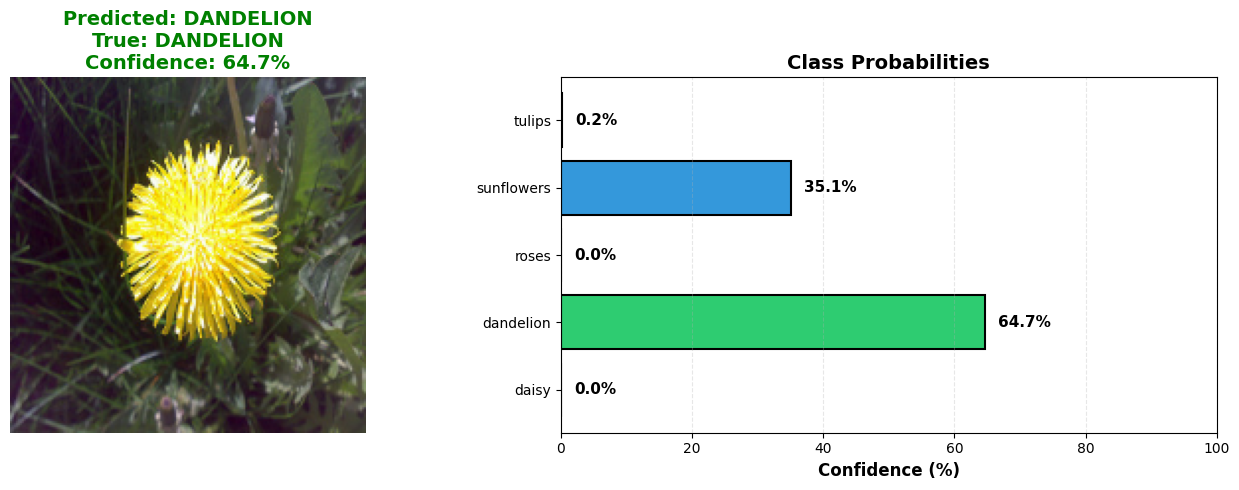


PREDICTION RESULT ON ONE TEST IMAGE
True Class:      DANDELION
Predicted Class: DANDELION
Confidence:      64.70%
Status:          Correct

Detailed class probabilities:
----------------------------------------------------------------------
1. dandelion      :  64.7% ================================ <- PREDICTED
2. sunflowers     :  35.1% =================
3. tulips         :   0.2% 
4. daisy          :   0.0% 
5. roses          :   0.0% 
----------------------------------------------------------------------


In [14]:
# ===============================================
# 14) Test Best Model On One Sample Image
# ===============================================

print("Testing best model with one image from test data...")

for test_images, test_labels in test_ds.take(1):
    sample_image = test_images[0]
    sample_label = test_labels[0]

    sample_input = tf.expand_dims(sample_image, 0)

    predictions = best_model.predict(sample_input, verbose=0)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[np.argmax(score)]
    true_class = class_names[sample_label.numpy()]
    confidence = 100 * np.max(score)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.imshow(sample_image)
    ax1.axis("off")

    if predicted_class == true_class:
        title_color = "green"
    else:
        title_color = "red"

    ax1.set_title(
        f"Predicted: {predicted_class.upper()}\n"
        f"True: {true_class.upper()}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=14,
        fontweight="bold",
        color=title_color
    )

    probs = [100 * score[i].numpy() for i in range(num_classes)]
    colors = ["#2ecc71" if i == np.argmax(score) else "#3498db" for i in range(num_classes)]

    bars = ax2.barh(
        class_names,
        probs,
        color=colors,
        edgecolor="black",
        linewidth=1.5
    )

    ax2.set_xlabel("Confidence (%)", fontsize=12, fontweight="bold")
    ax2.set_title("Class Probabilities", fontsize=14, fontweight="bold")
    ax2.set_xlim(0, 100)
    ax2.grid(axis="x", alpha=0.3, linestyle="--")

    for i, (bar, prob) in enumerate(zip(bars, probs)):
        ax2.text(
            prob + 2,
            i,
            f"{prob:.1f}%",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    print(f"\n{'=' * 70}")
    print("PREDICTION RESULT ON ONE TEST IMAGE")
    print(f"{'=' * 70}")
    print(f"True Class:      {true_class.upper()}")
    print(f"Predicted Class: {predicted_class.upper()}")
    print(f"Confidence:      {confidence:.2f}%")
    print(f"Status:          {'Correct' if predicted_class == true_class else 'Wrong'}")
    print(f"{'=' * 70}\n")

    print("Detailed class probabilities:")
    print("-" * 70)

    sorted_indices = np.argsort(probs)[::-1]

    for rank, idx in enumerate(sorted_indices, 1):
        name = class_names[idx]
        prob = probs[idx]
        bar_length = int(prob / 2)
        bar = "=" * bar_length
        marker = " <- PREDICTED" if idx == np.argmax(score) else ""
        print(f"{rank}. {name:15s}: {prob:5.1f}% {bar}{marker}")

    print("-" * 70)

    break

In [15]:
# ===============================================
# 15) Finish
# ===============================================

print("\n" + "=" * 70)
print("ALL TASKS COMPLETED!")
print("=" * 70)


ALL TASKS COMPLETED!
